In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

In [8]:
u = np.array([2, 1])
v = np.array([1, 2])

# Change v to [4, 2] to see a dependent pair.
A = np.column_stack([u, v])
det = np.linalg.det(A)

print(f"Determinant: {det:.2f}")

Determinant: 3.00


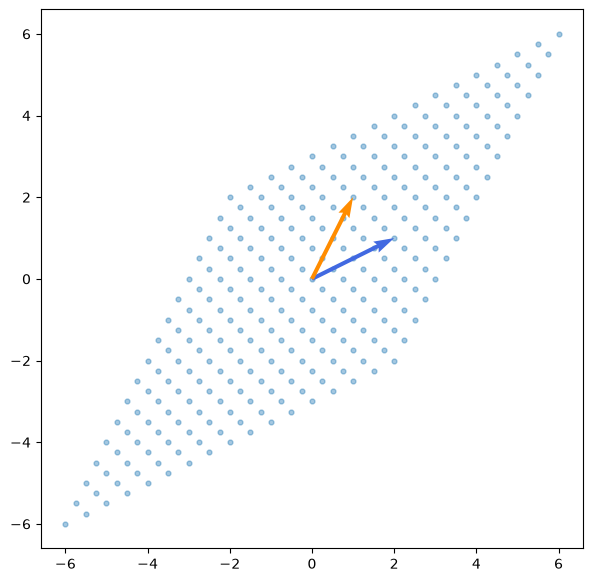

In [9]:
# Plot combinations a*u + b*v.
coefficients = np.linspace(-2, 2, 17)
points = np.array([
    a * u + b * v
    for a in coefficients
    for b in coefficients
])

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    points[:, 0], points[:, 1],
    s=12, alpha=0.4, label="Sampled linear combinations"
)

for vector, color, label in [
    (u, "royalblue", "u"),
    (v, "darkorange", "v"),
]:
    ax.quiver(
        0, 0, *vector,
        angles="xy", scale_units="xy", scale=1,
        color=color, label=label
    )

In [11]:
limit = np.max(np.abs(points)) + 1
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_aspect("equal")
ax.grid(alpha=0.2)
ax.legend()
ax.set_title(f"Linear combinations of u and v | det(A) = {det:.2f}")

fig.savefig(figures_dir / "linear_combinations.png", dpi=150)
plt.show()